In [1]:
from langchain_ibm import ChatWatsonx

In [2]:
### Basic deep agent

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["WATSONX_API_KEY"]=os.getenv("WATSONX_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["WATSONX_PROJECT_ID"]=os.getenv("WATSONX_PROJECT_ID")
os.environ["WATSONX_URL"]= os.getenv("WATSONX_URL","https://us-south.ml.cloud.ibm.com")

In [3]:
## Tools- Internet search
from tavily import TavilyClient
from typing import Literal

tavily_client=TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def web_search(query:str,max_results:int=5,
topic: Literal["general","sports","news","finance"]="general",
include_raw_content:bool=False):
    """Run a web search"""
    return tavily_client.search(query,
    max_results=max_results,include_raw_content=include_raw_content,topic=topic)



In [5]:
# from langchain.chat_models import init_chat_model
# model=init_chat_model("groq:qwen/qwen3-32b")
# model
WATSONX_APIKEY = os.getenv('WATSONX_API_KEY', None)
WATSONX_PROJECT_ID = os.getenv('WATSONX_PROJECT_ID', None)
URL = os.getenv("WATSONX_URL","https://us-south.ml.cloud.ibm.com")

model = ChatWatsonx(
    model_id="meta-llama/llama-3-3-70b-instruct",
    url = URL,
    apikey = WATSONX_APIKEY,
    project_id = WATSONX_PROJECT_ID,
)
model

ChatWatsonx(output_version=None, model_id='meta-llama/llama-3-3-70b-instruct', project_id='eb268969-82f4-4328-9165-2fee07125369', url=SecretStr('**********'), apikey=SecretStr('**********'), api_key=SecretStr('**********'), token=None, password=None, username=None, instance_id=None, params={}, watsonx_model=<ibm_watsonx_ai.foundation_models.inference.model_inference.ModelInference object at 0x11be55190>)

### Simple Agent

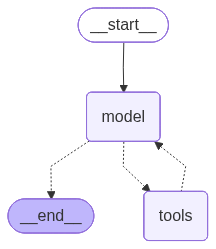

In [6]:
from langchain.agents import create_agent

simple_agent=create_agent(
    model=model,
    tools=[web_search]
)
simple_agent

### Deep Agent

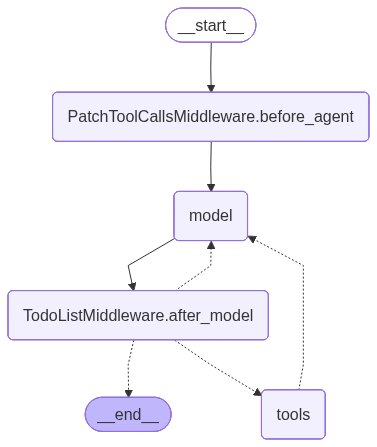

In [7]:
from deepagents import create_deep_agent

deepagent=create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt="Act as a researcher"
)
deepagent

In [8]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='10b7f6bb-d117-4bb0-a1eb-7107f42db903'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 5369, 'total_tokens': 5413}, 'model_name': 'meta-llama/llama-3-3-70b-instruct', 'system_fingerprint': '', 'finish_reason': 'tool_calls'}, id='chatcmpl-6096764b866f5ecda54ad08a49548daa', tool_calls=[{'name': 'web_search', 'args': {'query': 'deepagent', 'max_results': 5, 'include_raw_content': False, 'topic': 'general'}, 'id': 'chatcmpl-tool-ff419314bbe745868374aec06cf58273', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 5369, 'output_tokens': 44, 'total_tokens': 5413}),
  ToolMessage(content='{"query": "deepagent", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://github.com/langchain-ai/deepagents", "title": "GitHub - langchain-ai/deepagents: Python & Ty

In [9]:
result["messages"][-1].content

'Deepagent is a general reasoning agent with scalable toolsets, capable of tackling general tasks by searching for and using the appropriate tools from over 16,000 RapidAPIs in an end-to-end agentic reasoning process. It can create AI-powered apps, chatbots, and automate complex research. Deepagent is also a Python & TypeScript agent harness that provides an opinionated, ready-to-run agent out of the box, allowing users to create and manage agents with ease.'

### Customizing Deep Agents

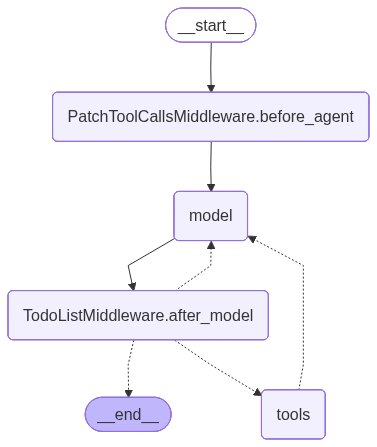

In [11]:
from langchain.chat_models import init_chat_model
from deepagents import create_deep_agent

agent = create_deep_agent(model=model)
agent

In [12]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='2e6ac34f-f741-4b6b-b18e-a08c9f4aef5e'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 5196, 'total_tokens': 5234}, 'model_name': 'meta-llama/llama-3-3-70b-instruct', 'system_fingerprint': '', 'finish_reason': 'tool_calls'}, id='chatcmpl-cc3bcc911f429dca6573e47901ec343f', tool_calls=[{'name': 'grep', 'args': {'pattern': 'deepagent', 'output_mode': 'files_with_matches', 'glob': '*.txt'}, 'id': 'chatcmpl-tool-f6823255bef74ec180b6d7f209d3042c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 5196, 'output_tokens': 38, 'total_tokens': 5234}),
  ToolMessage(content='No matches found', name='grep', id='a0e975d1-8100-4080-b03a-ee658848ba0c', tool_call_id='chatcmpl-tool-f6823255bef74ec180b6d7f209d3042c'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'token_usage': {'

#### System Prompt


In [13]:
from deepagents import create_deep_agent

research_instructions = """\
You are an expert researcher. Your job is to conduct \
thorough research, and then write a polished report. \
"""

agent = create_deep_agent(
    model=model,
    system_prompt=research_instructions,
)
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='fbd17911-06a1-437e-a584-061a705d07fe'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 5218, 'total_tokens': 5253}, 'model_name': 'meta-llama/llama-3-3-70b-instruct', 'system_fingerprint': '', 'finish_reason': 'tool_calls'}, id='chatcmpl-2ecefe9b110b3f7883b3f96cb7f5aed7', tool_calls=[{'name': 'task', 'args': {'subagent_type': 'general-purpose', 'description': 'What is deepagent?'}, 'id': 'chatcmpl-tool-bdbc3a8a8f8e474882ef471083527c2b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 5218, 'output_tokens': 35, 'total_tokens': 5253}),
  ToolMessage(content='DeepAgent is a Python library for building conversational AI models. It provides a simple and efficient way to create chatbots and other conversational interfaces.', name='task', id='a42f9afe-6d04-4a75-be70-0f815660fc17', tool

In [14]:
### Tools
import os
from typing import Literal
from tavily import TavilyClient
from deepagents import create_deep_agent

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,
):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )

agent = create_deep_agent(
    model=model,
    tools=[internet_search]
)
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent in Agentic AI?"}]})
result

{'messages': [HumanMessage(content='What is deepagent in Agentic AI?', additional_kwargs={}, response_metadata={}, id='04f76d9f-5891-4bdf-a31d-d2b113fd73ce'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 5364, 'total_tokens': 5412}, 'model_name': 'meta-llama/llama-3-3-70b-instruct', 'system_fingerprint': '', 'finish_reason': 'tool_calls'}, id='chatcmpl-6ffab6710da251d5b32db896ca823776', tool_calls=[{'name': 'internet_search', 'args': {'query': 'deepagent Agentic AI', 'max_results': '5', 'topic': 'general', 'include_raw_content': 'false'}, 'id': 'chatcmpl-tool-57099eec1ac74362abf3d2d5e7190af3', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 5364, 'output_tokens': 48, 'total_tokens': 5412}),
  ToolMessage(content='{"query": "deepagent Agentic AI", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://10clouds.com/blog/a-i/deep-agent-ai-use-cases-w